────────────────────────────────────────────────────────────
Chapter 2 — All Experiments
────────────────────────────────────────────────────────────

▶ Fig 0 — Demand Profiles


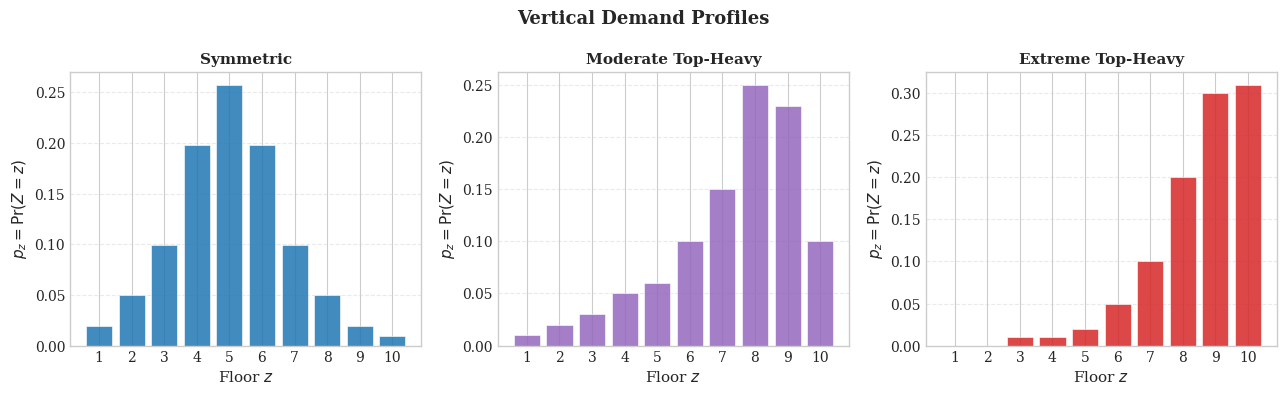


▶ Fig A — H(k) Profiles + Convexity Verification


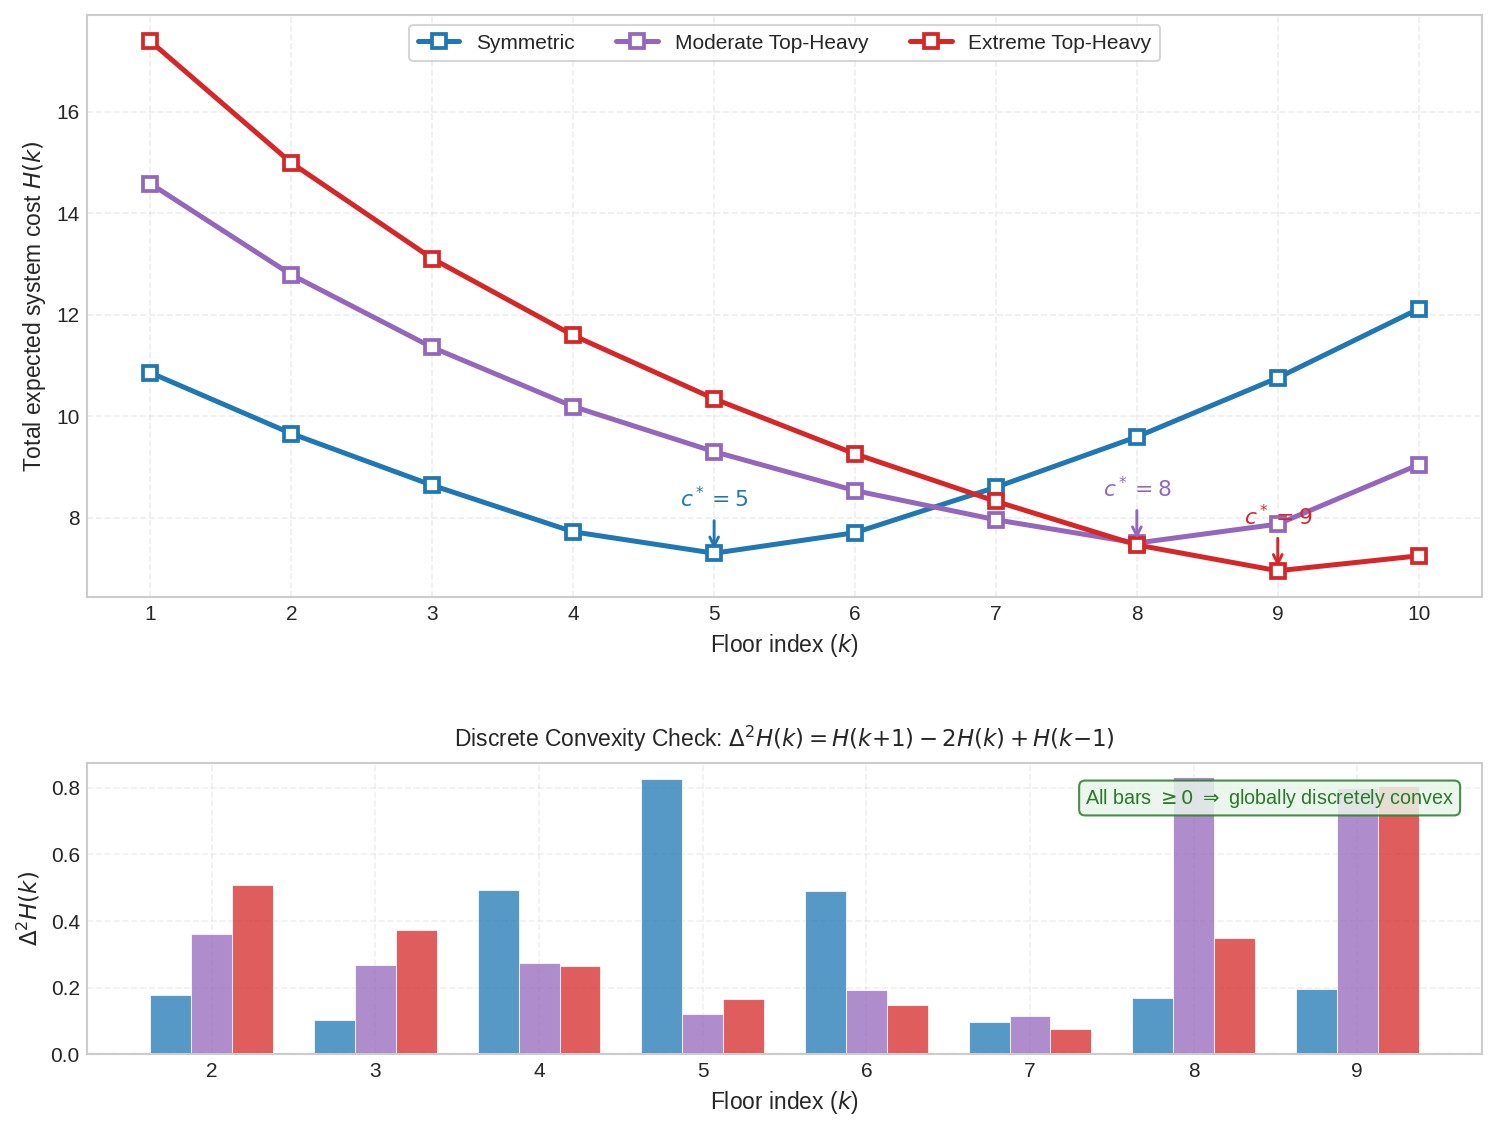


▶ Fig B — Convexity Failure (spatial-dominated regime only)


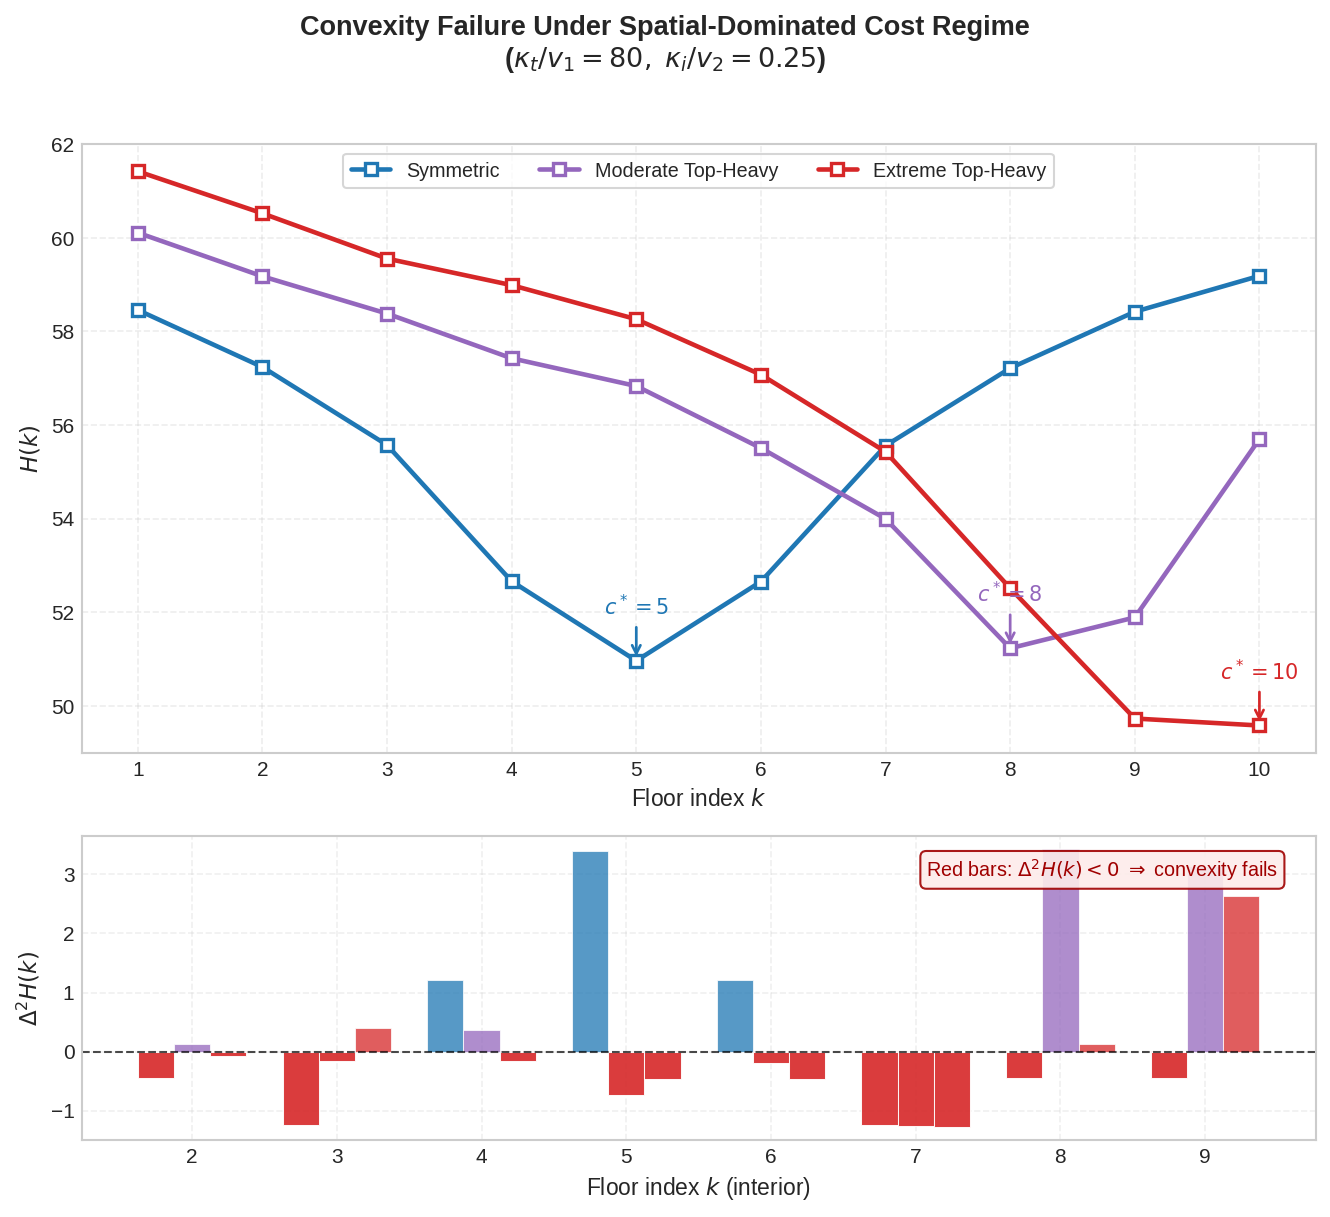


▶ Fig D — H at three policy floors vs Lambda


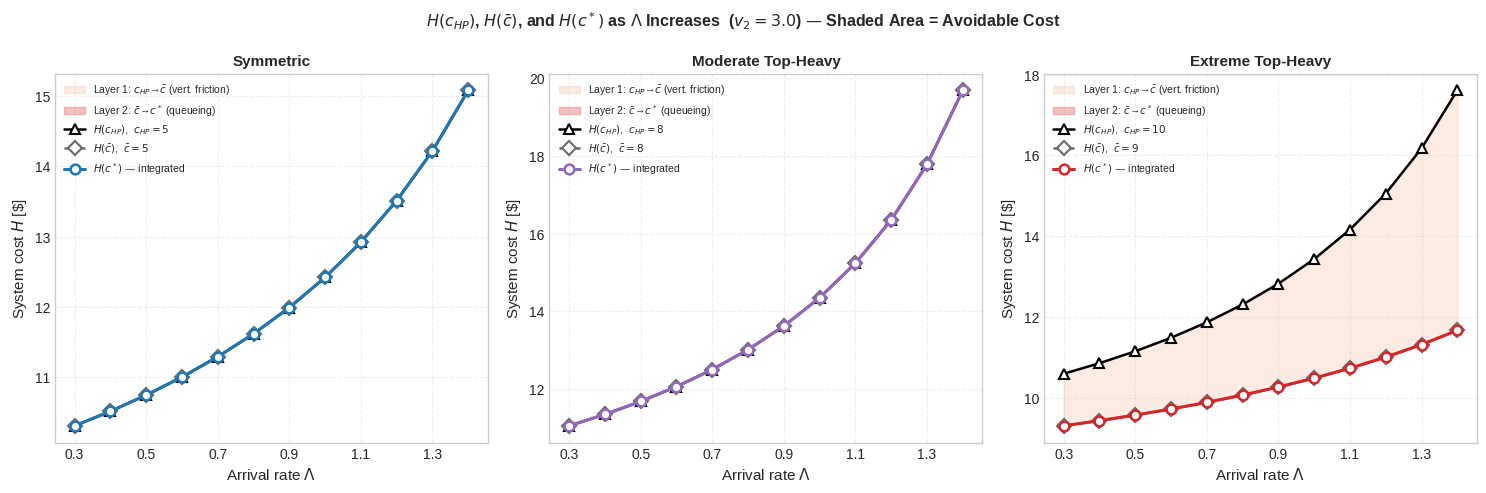


▶ Fig E — Cost Decomposition (Extreme Top-Heavy, Lambda=1.2)


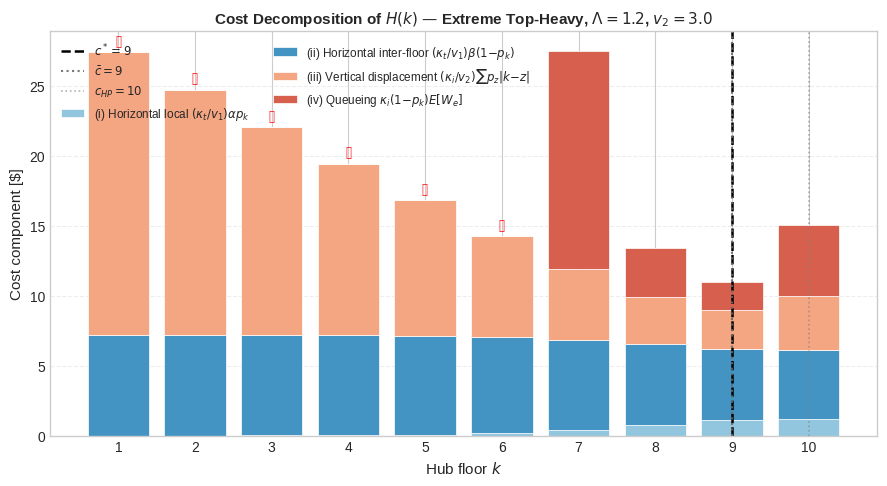


Done.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 11, 'axes.titlesize': 11,
    'legend.fontsize': 10, 'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})


#  PARAMETERS

M      = 10
FLOORS = np.arange(1, M + 1)

# Original parameters (Fig A, Fig B)
KT, KI  = 10.0, 8.0
V1      = 1.0
V2_ORIG = 12.0
ALPHA   = 0.38
BETA    = 0.72

# Corrected parameters (Fig D, Fig E, Table)
V2_CORR = 3.0

# Demand profiles
p_sym = np.array([0.02,0.05,0.10,0.20,0.26,0.20,0.10,0.05,0.02,0.01])
p_mod = np.array([0.01,0.02,0.03,0.05,0.06,0.10,0.15,0.25,0.23,0.10])
p_ext = np.array([0.00,0.00,0.01,0.01,0.02,0.05,0.10,0.20,0.30,0.31])
for p in (p_sym, p_mod, p_ext):
    p /= p.sum()

PROFILES  = [p_sym, p_mod, p_ext]
P_LABELS  = ['Symmetric', 'Moderate Top-Heavy', 'Extreme Top-Heavy']
P_COLORS  = ['#1f77b4', '#9467bd', '#d62728']
P_MARKERS = ['o', 's', '^']



def H_fixed_Lv(k, p_z, Lv, v2=V2_ORIG,
               kt_v1=KT/V1, ki_v2=None, ki=KI,
               alpha=ALPHA, beta=BETA):
    """H(k) with fixed Lambda_v — original parameterisation."""
    if ki_v2 is None:
        ki_v2 = ki / v2
    pk = p_z[k - 1]
    z  = np.arange(1, M + 1)
    T1  = kt_v1 * alpha * pk
    T2a = kt_v1 * beta  * (1 - pk)
    T2b = ki_v2 * np.dot(p_z, np.abs(k - z))
    if (1 - pk) < 1e-12 or Lv < 1e-12:
        return T1 + T2a + T2b
    mask   = (z != k)
    E_dist = np.dot(p_z[mask], np.abs(k - z[mask])) / (1 - pk)
    mu_e   = v2 / E_dist
    if mu_e <= Lv:
        return np.inf
    T3 = ki * (1 - pk) * Lv / (mu_e * (mu_e - Lv))
    return T1 + T2a + T2b + T3


def H_per_floor(k, p_z, Lambda, v2=V2_CORR,
                kt_v1=KT/V1, ki=KI,
                alpha=ALPHA, beta=BETA):
    """H(k) with floor-dependent Lambda_v = Lambda*(1-p_k)."""
    ki_v2 = ki / v2
    pk    = p_z[k - 1]
    z     = np.arange(1, M + 1)
    T1    = kt_v1 * alpha * pk
    T2a   = kt_v1 * beta  * (1 - pk)
    T2b   = ki_v2 * np.dot(p_z, np.abs(k - z))
    Lv    = Lambda * (1 - pk)
    if Lv < 1e-12 or (1 - pk) < 1e-12:
        return T1 + T2a + T2b
    mask   = (z != k)
    E_dist = np.dot(p_z[mask], np.abs(k - z[mask])) / (1 - pk)
    mu_e   = v2 / E_dist
    if mu_e <= Lv:
        return np.inf
    T3 = ki * (1 - pk) * Lv / (mu_e * (mu_e - Lv))
    return T1 + T2a + T2b + T3


def E_floor(k, p_z, kt_v1=KT/V1, ki_v2=KI/V2_ORIG,
            alpha=ALPHA, beta=BETA):
    """Distance-only objective E(k) — no queueing term."""
    pk = p_z[k - 1]
    z  = np.arange(1, M + 1)
    return (kt_v1*alpha*pk
            + kt_v1*beta*(1 - pk)
            + ki_v2*np.dot(p_z, np.abs(k - z)))


def H_vec_fixed(p_z, Lv, **kw):
    return np.array([H_fixed_Lv(k, p_z, Lv, **kw) for k in FLOORS])

def H_vec_corr(p_z, Lambda, **kw):
    return np.array([H_per_floor(k, p_z, Lambda, **kw) for k in FLOORS])

def E_vec(p_z, **kw):
    return np.array([E_floor(k, p_z, **kw) for k in FLOORS])


def c_star(Hv):
    fin = ~np.isinf(Hv)
    return int(np.argmin(Hv)) + 1 if fin.any() else None

def c_HP(p_z):
    return int(np.argmax(p_z)) + 1

def c_bar(p_z):
    """c_bar = argmin_k E(k) — distance-only optimal floor."""
    return int(np.argmin(E_vec(p_z))) + 1

def sav(Hb, Ho):
    if np.isinf(Hb) or Hb <= 0 or np.isnan(Ho):
        return np.nan
    return 100.0 * (Hb - Ho) / Hb



#   Demand profiles

def plot_demand_profiles():
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, p_z, lbl, col in zip(axes, PROFILES, P_LABELS, P_COLORS):
        ax.bar(FLOORS, p_z, color=col, alpha=0.85,
               edgecolor='white', lw=0.5)
        ax.set_title(lbl, fontweight='bold')
        ax.set_xlabel('Floor $z$')
        ax.set_ylabel('$p_z = \\Pr(Z=z)$')
        ax.set_xticks(FLOORS)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        ax.grid(axis='y', ls='--', alpha=0.4)
    fig.suptitle('Vertical Demand Profiles',
                 fontsize=13, fontweight='bold')
    fig.tight_layout()
    plt.show()


#   H(k) profiles + convexity verification

def plot_Hk_convexity(Lv=0.8):
    all_costs, all_d2 = [], []
    for p_z in PROFILES:
        cv = H_vec_fixed(p_z, Lv)
        all_costs.append(cv)
        all_d2.append(np.diff(np.diff(cv)))

    plt.style.use('seaborn-v0_8-whitegrid')
    fig = plt.figure(figsize=(12, 9), dpi=150)
    gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1.5], hspace=0.38)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])

    for cv, lbl, col in zip(all_costs, P_LABELS, P_COLORS):
        fv = np.where(np.isinf(cv), np.nan, cv)
        ax1.plot(FLOORS, fv, color=col, label=lbl, lw=2.4,
                 marker='s', ms=7,
                 markerfacecolor='white', markeredgewidth=1.8)
        mi = int(np.nanargmin(fv))
        ax1.annotate(
            rf'$c^*={FLOORS[mi]}$',
            xy=(FLOORS[mi], fv[mi]), xytext=(0, 22),
            textcoords='offset points', ha='center',
            fontsize=10.5, fontweight='bold', color=col,
            arrowprops=dict(arrowstyle='->', color=col, lw=1.4)
        )

    ax1.set_xlabel('Floor index ($k$)', fontsize=11)
    ax1.set_ylabel(r'Total expected system cost $H(k)$', fontsize=11)
    ax1.set_xticks(FLOORS)
    ax1.legend(frameon=True, fontsize=10, loc='upper center', ncol=3)
    ax1.grid(alpha=0.35, ls='--')

    bw   = 0.25
    interior = FLOORS[1:-1]
    offs = [-bw, 0, bw]
    for d2, col, off in zip(all_d2, P_COLORS, offs):
        ax2.bar(interior + off, d2, width=bw, color=col,
                alpha=0.75, edgecolor='white', lw=0.5)
    ax2.axhline(0, color='black', lw=1.0, ls='--', alpha=0.6)
    ax2.set_title(
        r'Discrete Convexity Check: '
        r'$\Delta^2H(k)=H(k{+}1)-2H(k)+H(k{-}1)$',
        fontsize=11, pad=8)
    ax2.set_xlabel('Floor index ($k$)', fontsize=11)
    ax2.set_ylabel(r'$\Delta^2H(k)$', fontsize=11)
    ax2.set_xticks(interior)
    ax2.text(
        0.98, 0.92,
        r'All bars $\geq0$ $\Rightarrow$ globally discretely convex',
        transform=ax2.transAxes, ha='right', va='top',
        fontsize=9.5, color='#2a7a2a',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#e8f5e9',
                  edgecolor='#2a7a2a', alpha=0.85))
    ax2.grid(alpha=0.3, ls='--')
    fig.tight_layout()
    plt.show()


# Convexity violation (spatial-dominated regime ONLY)

def plot_convexity_violation(Lv=0.8):
    kt_v1 = 80.0
    ki_v2 = 0.25
    ki    = 3.0

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(9, 8),
        gridspec_kw={'height_ratios': [3, 1.5]},
        dpi=150
    )
    fig.suptitle(
        r'Convexity Failure Under Spatial-Dominated Cost Regime'
        '\n'
        r'($\kappa_t/v_1=80,\;\kappa_i/v_2=0.25$)',
        fontsize=13, fontweight='bold', y=1.01
    )

    all_d2 = []
    for p_z, lbl, col in zip(PROFILES, P_LABELS, P_COLORS):
        cv = np.array([
            H_fixed_Lv(k, p_z, Lv, V2_ORIG,
                       kt_v1=kt_v1, ki_v2=ki_v2, ki=ki)
            for k in FLOORS
        ])
        fv = np.where(np.isinf(cv), np.nan, cv)
        ax_top.plot(FLOORS, fv, color=col, label=lbl, lw=2.2,
                    marker='s', ms=6,
                    markerfacecolor='white', markeredgewidth=1.6)
        mi = int(np.nanargmin(fv))
        ax_top.annotate(
            rf'$c^*={FLOORS[mi]}$',
            xy=(FLOORS[mi], fv[mi]), xytext=(0, 22),
            textcoords='offset points', ha='center',
            fontsize=10, fontweight='bold', color=col,
            arrowprops=dict(arrowstyle='->', color=col, lw=1.3)
        )
        fin = np.isfinite(cv)
        fc  = cv[fin]; fl = FLOORS[fin]
        if len(fc) >= 3:
            all_d2.append((np.diff(np.diff(fc)), fl[1:-1], col))

    ax_top.set_xlabel('Floor index $k$', fontsize=11)
    ax_top.set_ylabel(r'$H(k)$', fontsize=11)
    ax_top.set_xticks(FLOORS)
    ax_top.legend(fontsize=9.5, loc='upper center', ncol=3, frameon=True)
    ax_top.grid(alpha=0.35, ls='--')

    bw   = 0.25
    offs = [-bw, 0, bw]
    for (d2, intr, col), off in zip(all_d2, offs):
        bars = ax_bot.bar(intr + off, d2, width=bw, color=col,
                          alpha=0.75, edgecolor='white', lw=0.5)
        for patch, val in zip(bars, d2):
            if val < 0:
                patch.set_facecolor('#d62728')
                patch.set_alpha(0.9)

    ax_bot.axhline(0, color='black', lw=1.0, ls='--', alpha=0.7)
    ax_bot.set_xlabel('Floor index $k$ (interior)', fontsize=11)
    ax_bot.set_ylabel(r'$\Delta^2H(k)$', fontsize=11)
    ax_bot.set_xticks(FLOORS[1:-1])
    ax_bot.grid(alpha=0.3, ls='--')
    ax_bot.text(
        0.97, 0.93,
        r'Red bars: $\Delta^2H(k)<0$ $\Rightarrow$ convexity fails',
        transform=ax_bot.transAxes, ha='right', va='top',
        fontsize=9.5, color='#a00000',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdecea',
                  edgecolor='#a00000', alpha=0.9)
    )
    fig.tight_layout()
    plt.show()




#  FIG D — H at three policy floors vs Lambda

def plot_savings_vs_lambda(v2=V2_CORR, lam_min=0.3, lam_max=1.4, n=12):
    lambdas = np.linspace(lam_min, lam_max, n)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

    for ax, p_z, lbl, col in zip(axes, PROFILES, P_LABELS, P_COLORS):
        H_at_HP, H_at_cb, H_at_cs = [], [], []
        cHP = c_HP(p_z)
        cb  = c_bar(p_z)

        for lam in lambdas:
            Hv = H_vec_corr(p_z, lam, v2=v2)
            cs = c_star(Hv)
            H_at_HP.append(Hv[cHP - 1] if np.isfinite(Hv[cHP-1])
                           else np.nan)
            H_at_cb.append(Hv[cb  - 1])
            H_at_cs.append(Hv[cs  - 1] if cs else np.nan)

        Hhp = np.array(H_at_HP)
        Hcb = np.array(H_at_cb)
        Hcs = np.array(H_at_cs)

        # shade Layer 1 and Layer 2 savings
        ax.fill_between(lambdas, Hcb, Hhp,
                        where=(Hhp >= Hcb),
                        alpha=0.22, color='#f4a582',
                        label=f'Layer 1: $c_{{HP}}$→$\\bar{{c}}$ (vert. friction)')
        ax.fill_between(lambdas, Hcs, Hcb,
                        alpha=0.28, color='#d62728',
                        label=f'Layer 2: $\\bar{{c}}$→$c^*$ (queueing)')

        # three policy cost lines
        ax.plot(lambdas, Hhp, 'k-^', lw=1.8, ms=7,
                markerfacecolor='white', markeredgewidth=1.5,
                label=rf'$H(c_{{HP}})$,  $c_{{HP}}={cHP}$')
        ax.plot(lambdas, Hcb, color='dimgray', ls='--',
                marker='D', lw=1.8, ms=7,
                markerfacecolor='white', markeredgewidth=1.5,
                label=rf'$H(\bar{{c}})$,  $\bar{{c}}={cb}$')
        ax.plot(lambdas, Hcs, color=col, ls='-',
                marker='o', lw=2.2, ms=7,
                markerfacecolor='white', markeredgewidth=1.8,
                label=r'$H(c^*)$ — integrated')

        ax.set_title(lbl, fontweight='bold')
        ax.set_xlabel(r'Arrival rate $\Lambda$')
        ax.set_ylabel(r'System cost $H$ [\$]')
        ax.legend(fontsize=7.5, loc='best')
        ax.grid(ls='--', alpha=0.3)
        ax.set_xticks(np.round(lambdas[::2], 1))

    fig.suptitle(
        rf'$H(c_{{HP}})$, $H(\bar{{c}})$, and $H(c^*)$ as $\Lambda$ Increases'
        rf'  ($v_2={v2}$) — Shaded Area = Avoidable Cost',
        fontsize=11.5, fontweight='bold'
    )
    fig.tight_layout()
    plt.show()


# ════════════════════════════════════════════════════════════════
#  FIG E — Cost decomposition (stacked bar)
# ════════════════════════════════════════════════════════════════
def plot_decomposition(p_z=None, Lambda=1.2, v2=V2_CORR,
                       label='Extreme Top-Heavy'):
    if p_z is None:
        p_z = p_ext
    ki_v2 = KI / v2
    T1v, T2av, T2bv, T3v = [], [], [], []

    for k in FLOORS:
        pk  = p_z[k - 1]
        z   = np.arange(1, M + 1)
        t1  = (KT / V1) * ALPHA * pk
        t2a = (KT / V1) * BETA  * (1 - pk)
        t2b = ki_v2 * np.dot(p_z, np.abs(k - z))
        Lv  = Lambda * (1 - pk)
        if Lv < 1e-12 or (1 - pk) < 1e-12:
            t3 = np.nan if Lv > 0 else 0.0
        else:
            mask = (z != k)
            Ed   = np.dot(p_z[mask], np.abs(k - z[mask])) / (1 - pk)
            mu_e = v2 / Ed
            t3   = (KI * (1 - pk) * Lv / (mu_e * (mu_e - Lv))
                    if mu_e > Lv else np.nan)
        T1v.append(t1); T2av.append(t2a)
        T2bv.append(t2b); T3v.append(t3)

    T1v  = np.array(T1v);  T2av = np.array(T2av)
    T2bv = np.array(T2bv); T3v  = np.array(T3v, dtype=float)

    fig, ax = plt.subplots(figsize=(9, 5))
    b0 = np.zeros(M)

    ax.bar(FLOORS, T1v, bottom=b0,
           color='#92c5de', edgecolor='white', lw=0.5,
           label=r'(i) Horizontal local $(\kappa_t/v_1)\alpha p_k$')
    b0 += T1v
    ax.bar(FLOORS, T2av, bottom=b0,
           color='#4393c3', edgecolor='white', lw=0.5,
           label=r'(ii) Horizontal inter-floor $(\kappa_t/v_1)\beta(1{-}p_k)$')
    b0 += T2av
    ax.bar(FLOORS, T2bv, bottom=b0,
           color='#f4a582', edgecolor='white', lw=0.5,
           label=r'(iii) Vertical displacement $(\kappa_i/v_2)\sum p_z|k{-}z|$')
    b0 += T2bv
    T3p = np.where(np.isnan(T3v), 0, T3v)
    ax.bar(FLOORS, T3p, bottom=b0,
           color='#d6604d', edgecolor='white', lw=0.5,
           label=r'(iv) Queueing $\kappa_i(1{-}p_k)E[W_e]$')

    for ki in range(M):
        if np.isnan(T3v[ki]):
            ax.text(ki + 1, b0[ki] + 0.4, '✗',
                    ha='center', color='red',
                    fontsize=13, fontweight='bold')

    Hv  = H_vec_corr(p_z, Lambda, v2=v2)
    cs_ = c_star(Hv)
    cH_ = c_HP(p_z)
    cb_ = c_bar(p_z)

    if cs_:
        ax.axvline(cs_, color='black', ls='--', lw=1.8,
                   label=f'$c^*={cs_}$')
    ax.axvline(cb_, color='dimgray', ls=':', lw=1.5, alpha=0.9,
               label=f'$\\bar{{c}}={cb_}$')
    ax.axvline(cH_, color='gray', ls=':', lw=1.2, alpha=0.6,
               label=f'$c_{{HP}}={cH_}$')

    ax.set_xticks(FLOORS)
    ax.set_xlabel('Hub floor $k$')
    ax.set_ylabel(r'Cost component [\$]')
    ax.set_title(
        rf'Cost Decomposition of $H(k)$ — {label}, '
        rf'$\Lambda={Lambda}$, $v_2={v2}$',
        fontweight='bold'
    )
    ax.legend(loc='upper left', fontsize=8.5, ncol=2)
    ax.grid(axis='y', ls='--', alpha=0.35)
    fig.tight_layout()
    plt.show()


print('─' * 60)
print('Chapter 2 — All Experiments')
print('─' * 60)

print('\n▶ Fig 0 — Demand Profiles')
plot_demand_profiles()

print('\n▶ Fig A — H(k) Profiles + Convexity Verification')
plot_Hk_convexity(Lv=0.8)

print('\n▶ Fig B — Convexity Failure (spatial-dominated regime only)')
plot_convexity_violation(Lv=0.8)

# print('\n▶ Table 2.3 — Verification with original fixed Lambda_v=0.8')
# print_verification_table(Lv_fixed=0.8)

# print('\n▶ Table 2.3 — Verification with floor-dependent Lambda_v(k)')
# print_verification_table(Lv_fixed=None)

print('\n▶ Fig D — H at three policy floors vs Lambda')
plot_savings_vs_lambda()

print('\n▶ Fig E — Cost Decomposition (Extreme Top-Heavy, Lambda=1.2)')
plot_decomposition(p_z=p_ext, Lambda=1.2, label='Extreme Top-Heavy')

print('\nDone.')

In [9]:
#cost savings table

import numpy as np
import warnings
warnings.filterwarnings('ignore')

M = 10
FLOORS = np.arange(1, M + 1)
KT = 5.0
V1 = 1.0
ALPHA = 0.38
BETA  = 0.72

def norm(p):
    p = np.array(p, float)
    return p / p.sum()

# Demand profiles
PROF_T1 = {
    'Moderate Top-Heavy':
        norm([0.01,0.02,0.03,0.05,0.06,0.10,0.15,0.25,0.23,0.10]),
    'Extreme Top-Heavy':
        norm([0.00,0.00,0.01,0.01,0.02,0.05,0.10,0.20,0.30,0.31]),
    'Bimodal (fl.2 & 9)':
        norm([0.02,0.35,0.04,0.02,0.01,0.01,0.02,0.04,0.38,0.11]),
    'Bimodal (fl.3 & 8)':
        norm([0.02,0.04,0.30,0.04,0.02,0.02,0.02,0.34,0.12,0.08]),
    'Triple peak fl.2,6,10':
        norm([0.01,0.28,0.02,0.01,0.01,0.30,0.02,0.01,0.01,0.33]),
    'fl.1 dominant':
        norm([0.45,0.08,0.06,0.05,0.05,0.05,0.06,0.07,0.07,0.06]),
    'fl.10 dominant':
        norm([0.06,0.07,0.07,0.06,0.05,0.05,0.05,0.06,0.08,0.45]),
    'Bottom heavy + top tail':
        norm([0.30,0.20,0.10,0.06,0.04,0.04,0.06,0.08,0.08,0.04]),
    'Top heavy + bottom tail':
        norm([0.04,0.08,0.08,0.06,0.04,0.04,0.06,0.10,0.20,0.30]),
}

PROF_T2 = {
    'Bimodal (fl.2 & 9)':
        norm([0.02,0.35,0.04,0.02,0.01,0.01,0.02,0.04,0.38,0.11]),
    'Bimodal (fl.3 & 8)':
        norm([0.02,0.04,0.30,0.04,0.02,0.02,0.02,0.34,0.12,0.08]),
    'fl.1 dominant':
        norm([0.45,0.08,0.06,0.05,0.05,0.05,0.06,0.07,0.07,0.06]),
    'fl.10 dominant':
        norm([0.06,0.07,0.07,0.06,0.05,0.05,0.05,0.06,0.08,0.45]),
    'Deep valley fl.5 (peaks 2&9)':
        norm([0.02,0.32,0.06,0.04,0.01,0.01,0.04,0.06,0.36,0.08]),
    'Bimodal fl.1 & 8':
        norm([0.38,0.06,0.03,0.02,0.01,0.01,0.02,0.35,0.08,0.04]),
    'Bimodal fl.1 & 10':
        norm([0.40,0.04,0.02,0.01,0.01,0.01,0.01,0.02,0.04,0.44]),
    'Asymmetric valley fl.6':
        norm([0.03,0.04,0.25,0.08,0.03,0.01,0.02,0.05,0.30,0.19]),
    'Strong fl.3 + fl.9':
        norm([0.02,0.03,0.38,0.04,0.02,0.02,0.03,0.04,0.36,0.06]),
    'Extreme bimodal fl.2&10':
        norm([0.01,0.44,0.01,0.01,0.01,0.01,0.01,0.01,0.04,0.45]),
}


def H_k(k, p, Lam, v2, ki):
    kv = ki / v2; kt = KT / V1
    pk = p[k - 1]; z = np.arange(1, M + 1)
    T1  = kt * ALPHA * pk
    T2a = kt * BETA  * (1 - pk)
    T2b = kv * np.dot(p, np.abs(k - z))
    Lv  = Lam * (1 - pk)
    if Lv < 1e-12 or (1 - pk) < 1e-12:
        return T1 + T2a + T2b
    mask = (z != k)
    Ed   = np.dot(p[mask], np.abs(k - z[mask])) / (1 - pk)
    mu_e = v2 / Ed
    if mu_e <= Lv:
        return np.inf
    return T1 + T2a + T2b + ki * (1 - pk) * Lv / (mu_e * (mu_e - Lv))

def E_k(k, p, v2, ki):
    kv = ki / v2; kt = KT / V1
    pk = p[k - 1]; z = np.arange(1, M + 1)
    return (kt * ALPHA * pk
            + kt * BETA * (1 - pk)
            + kv * np.dot(p, np.abs(k - z)))

def cs_f(Hv):
    fin = ~np.isinf(Hv)
    return int(np.argmin(Hv)) + 1 if fin.any() else None

def cHP_f(p):
    return int(np.argmax(p)) + 1

def cb_f(p, v2, ki):
    return int(np.argmin([E_k(k, p, v2, ki) for k in FLOORS])) + 1

def sav(Hb, Ho):
    if np.isinf(Hb) or Hb <= 0 or np.isnan(Ho):
        return np.nan
    return 100.0 * (Hb - Ho) / Hb


T1 = []
for name, p in PROF_T1.items():
    for ki in [10, 15, 20, 25, 30, 40, 50]:
        for Lam in np.round(np.arange(0.20, 1.51, 0.05), 2):
            for v2 in [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0]:
                Hv  = np.array([H_k(k, p, Lam, v2, ki) for k in FLOORS])
                cHP = cHP_f(p)
                cs  = cs_f(Hv)
                if cs is None:
                    continue
                H_cHP = Hv[cHP - 1]
                H_cs  = Hv[cs  - 1]
                s = sav(H_cHP, H_cs)
                if cHP != cs and not np.isnan(s) and 5 < s < 70:
                    T1.append(dict(name=name, p=p,
                                   Lam=Lam, v2=v2, ki=ki,
                                   ki_kt=ki/KT,
                                   cHP=cHP, cs=cs,
                                   H_cHP=H_cHP, H_cs=H_cs, sav=s))

T2 = []
for name, p in PROF_T2.items():
    for ki in [5, 8, 10, 15, 20, 25, 30, 40, 50]:
        for Lam in np.round(np.arange(0.20, 1.51, 0.05), 2):
            for v2 in [0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0]:
                Hv = np.array([H_k(k, p, Lam, v2, ki) for k in FLOORS])
                cb = cb_f(p, v2, ki)
                cs = cs_f(Hv)
                if cs is None:
                    continue
                H_cb = Hv[cb - 1]
                H_cs = Hv[cs - 1]
                s = sav(H_cb, H_cs)
                if cb != cs and not np.isnan(s) and s > 1:
                    T2.append(dict(name=name, p=p,
                                   Lam=Lam, v2=v2, ki=ki,
                                   ki_kt=ki/KT,
                                   cb=cb, cs=cs,
                                   H_cb=H_cb, H_cs=H_cs, sav=s))

print(f'T1: {len(T1)} rows found  |  T2: {len(T2)} rows found')


def select6(rows, sav_key='sav'):
    # one row per profile: closest savings to 25%
    by_name = {}
    for r in rows:
        n = r['name']
        if n not in by_name:
            by_name[n] = []
        by_name[n].append(r)
    reps = []
    for n, rs in by_name.items():
        rs.sort(key=lambda x: abs(x[sav_key] - 25))
        reps.append(rs[0])
    # sort by savings magnitude, spread 6 evenly across range
    reps.sort(key=lambda x: x[sav_key])
    if len(reps) <= 6:
        return reps
    step = len(reps) / 6
    return [reps[int(i * step)] for i in range(6)]

T1_6 = select6(T1)
T2_6 = select6(T2)


# ── Print Table 1 ─────────────────────────────────────────────────
print()
print('=' * 100)
print('TABLE 1 — Integrated Model vs. Highest-Peak Heuristic')
print('  c_HP = argmax p_z     c* = argmin H(k)')
print('  Savings = [H(c_HP) - H(c*)] / H(c_HP) x 100')
print(f'  kappa_t={KT}, v1={V1}  |  Lambda_v(k) = Lambda*(1-p_k)')
print('=' * 100)
print(f"{'Demand Profile':<30} {'ki/kt':>6} {'Lambda':>7} {'v2':>5}"
      f"  {'c_HP':>4} {'c*':>4}"
      f"  {'H(c_HP)':>10} {'H(c*)':>10}  {'Savings':>8}")
print('-' * 100)
for r in T1_6:
    print(f"{r['name']:<30} {r['ki_kt']:>6.0f} {r['Lam']:>7.2f} {r['v2']:>5.1f}"
          f"  {r['cHP']:>4} {r['cs']:>4}"
          f"  {r['H_cHP']:>10.2f} {r['H_cs']:>10.2f}"
          f"  {r['sav']:>7.1f}%")
print('=' * 100)


# ── Print Table 2 ─────────────────────────────────────────────────
print()
print('=' * 100)
print('TABLE 2 — Integrated Model vs. Distance-Only Policy')
print('  c_bar = argmin E(k)   c* = argmin H(k)')
print('  Savings = [H(c_bar) - H(c*)] / H(c_bar) x 100')
print(f'  kappa_t={KT}, v1={V1}  |  Lambda_v(k) = Lambda*(1-p_k)')
print('=' * 100)
print(f"{'Demand Profile':<30} {'ki/kt':>6} {'Lambda':>7} {'v2':>5}"
      f"  {'c_bar':>5} {'c*':>4}"
      f"  {'H(c_bar)':>10} {'H(c*)':>10}  {'Savings':>8}")
print('-' * 100)
for r in T2_6:
    print(f"{r['name']:<30} {r['ki_kt']:>6.0f} {r['Lam']:>7.2f} {r['v2']:>5.1f}"
          f"  {r['cb']:>5} {r['cs']:>4}"
          f"  {r['H_cb']:>10.2f} {r['H_cs']:>10.2f}"
          f"  {r['sav']:>7.1f}%")
print('=' * 100)

T1: 1874 rows found  |  T2: 881 rows found

TABLE 1 — Integrated Model vs. Highest-Peak Heuristic
  c_HP = argmax p_z     c* = argmin H(k)
  Savings = [H(c_HP) - H(c*)] / H(c_HP) x 100
  kappa_t=5.0, v1=1.0  |  Lambda_v(k) = Lambda*(1-p_k)
Demand Profile                  ki/kt  Lambda    v2  c_HP   c*     H(c_HP)      H(c*)   Savings
----------------------------------------------------------------------------------------------------
Bimodal (fl.2 & 9)                 10    0.30   1.0     9    8     4340.79    3712.83     14.5%
Bottom heavy + top tail             3    0.60   3.0     1    2       36.50      27.47     24.7%
Top heavy + bottom tail             3    0.60   3.0    10    9       36.50      27.47     24.7%
Extreme Top-Heavy                   4    0.20   2.0    10    9       19.76      14.82     25.0%
fl.1 dominant                       2    0.65   2.0     1    2      132.25      98.96     25.2%
fl.10 dominant                      2    0.65   2.0    10    9      132.25      98.